## 1. Library Initialization and Dependencies

In [8]:
import gymnasium as gym
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from pathlib import Path
import os
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Hardware Acceleration Verification

In [3]:
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device count: {torch.cuda.device_count()}")
    print(f"Detected GPU: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")
else:
    print("No CUDA GPU detected in current runtime.")
    print("Expected target device: NVIDIA GeForce RTX 3070")

CUDA available: True
GPU device count: 1
Detected GPU: NVIDIA GeForce RTX 3070 Laptop GPU
Current CUDA device index: 0


## 3. Environment Initialization: MountainCar-v0

In [4]:
env = gym.make("MountainCar-v0", render_mode="rgb_array")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action space: Discrete(3)


## 4. Preliminary Baseline: Random Policy Evaluation

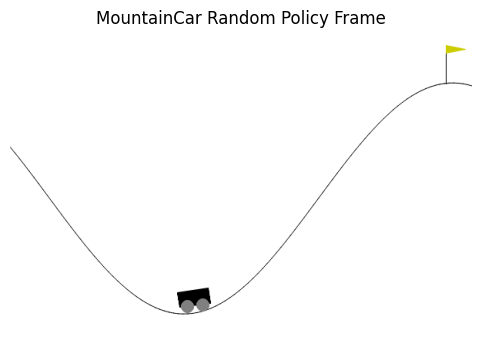

In [5]:
import matplotlib.pyplot as plt

obs, info = env.reset()
frame = None
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    frame = env.render()
    if terminated or truncated:
        obs, info = env.reset()

plt.figure(figsize=(6, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("MountainCar Random Policy Frame")
plt.show()

## 5. Model Training: Proximal Policy Optimization (PPO)

In [6]:
from pathlib import Path
from stable_baselines3.common.monitor import Monitor

log_dir = Path("logs_and_results")
log_dir.mkdir(parents=True, exist_ok=True)

train_env = Monitor(gym.make("MountainCar-v0"))
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    tensorboard_log=str(log_dir / "tensorboard_baseline"),
    device="cuda" if torch.cuda.is_available() else "cpu",
)
model.learn(total_timesteps=100_000, tb_log_name="ppo_mountain_car_baseline")
model.save(str(log_dir / "mountain_car_baseline"))
train_env.close()
print("Model saved to logs_and_results/mountain_car_baseline.zip")

Using cuda device
Wrapping the env in a DummyVecEnv.
Logging to logs_and_results\tensorboard_baseline\ppo_mountain_car_baseline_1


d:\CodeFiles\RL-Gymnasium-PACSPL602013-Final-Project\final_project_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -200     |
| time/              |          |
|    fps             | 639      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -200         |
| time/                   |              |
|    fps                  | 510          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0033289841 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.1         |
|    explained_variance   | 5.04e-05     |
|    learning_r

## 6. Results Visualization and Video Assessment

In [9]:
import imageio.v2 as imageio
from IPython.display import Video

model_path = "logs_and_results/mountain_car_baseline.zip"
video_path = "logs_and_results/mountain_car_baseline_demo.mp4"

loaded_model = PPO.load(model_path)
video_env = gym.make("MountainCar-v0", render_mode="rgb_array")

frames = []
obs, info = video_env.reset()
terminated = False
truncated = False
while not (terminated or truncated):
    frame = video_env.render()
    frames.append(frame)
    action, _ = loaded_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = video_env.step(action)

video_env.close()
imageio.mimsave(video_path, frames, fps=30)
Video(video_path, embed=True)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
